# Chapter 54 — Function Composition

> **Prerequisites:** ch051 (What is a Function?), ch052 (Functions as Programs), ch053 (Domain and Range)
> 
> **You will learn:**
> - Definition of function composition f ∘ g
> - Domain of the composition and when it is valid
> - Composition as the basis for building complex transformations from simple parts
> - Non-commutativity: f ∘ g ≠ g ∘ f in general
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Function composition** is the operation of applying one function to the result of another.

Given f : B → C and g : A → B, their composition is:
```
(f ∘ g)(x) = f(g(x))
```
Read: "f after g" or "f composed with g".

The composition takes an input from A, applies g to get something in B, then applies f to get something in C. The intermediate set B must be compatible: the range of g must be a subset of the domain of f.

**Composition is not commutative.** In general, f ∘ g ≠ g ∘ f. Example: f(x) = x + 1, g(x) = x². Then:
- (f ∘ g)(x) = f(g(x)) = x² + 1
- (g ∘ f)(x) = g(f(x)) = (x+1)²
These are different functions.

**Composition is associative.** f ∘ (g ∘ h) = (f ∘ g) ∘ h. Order of evaluation is fixed by nesting, not by grouping.

**Why it matters:** Every deep learning model is a composition of functions. A neural network with 100 layers is a composition of 100 simpler functions. Understanding composition is understanding deep learning's structure.

---

## 2. Intuition & Mental Models

**Physical analogy:** Assembly line. Each station is a function. The output of one station is the input of the next. The final product is the composition of all stations. The order of stations matters — welding before painting is different from painting before welding.

**Computational analogy:** UNIX pipes: `cat file | grep pattern | sort | uniq`. Each command is a function; `|` is composition. Data flows left to right. The output of `grep` must be valid input for `sort`. This is exactly `(uniq ∘ sort ∘ grep ∘ cat)(file)`.

Recall from ch052 (Functions as Programs): the `compose(*fns)` pipeline we built was exactly function composition. Now we give it formal mathematical treatment.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_5552\3042565820.py:36: UserWarning: Glyph 8728 (\N{RING OPERATOR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8728 (\N{RING OPERATOR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


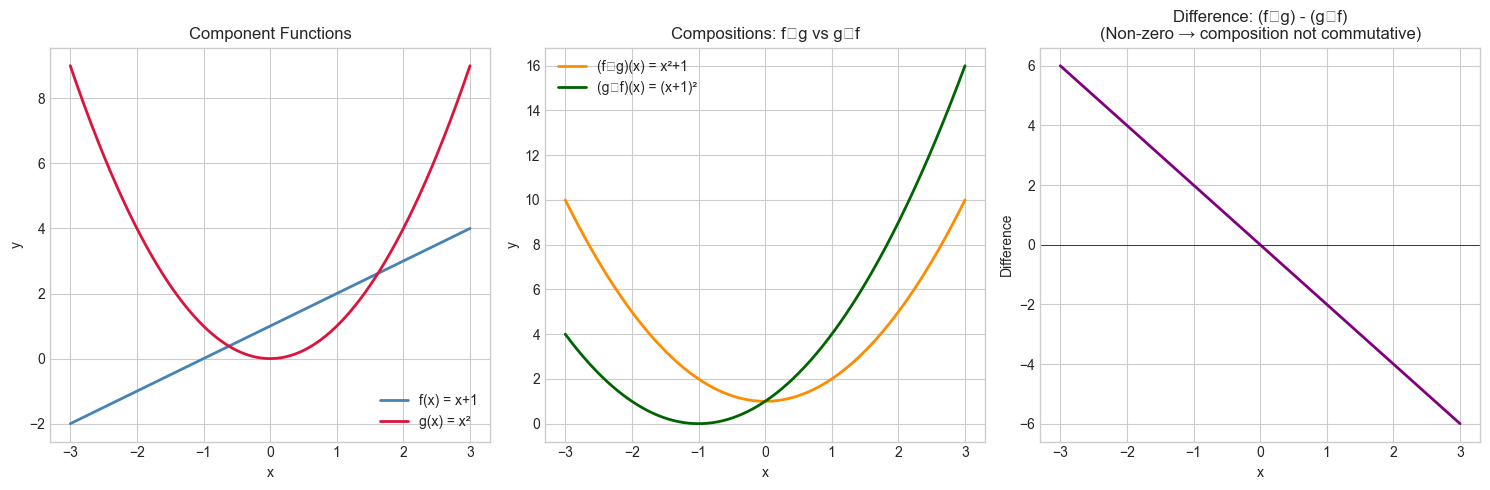

In [1]:
# --- Visualization: f∘g vs g∘f — order matters ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-3, 3, 400)

f = lambda x: x + 1       # shift up by 1
g = lambda x: x**2        # square
fog = lambda x: f(g(x))   # f after g: x² + 1
gof = lambda x: g(f(x))   # g after f: (x+1)²

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x, f(x), color='steelblue', linewidth=2, label='f(x) = x+1')
axes[0].plot(x, g(x), color='crimson', linewidth=2, label='g(x) = x²')
axes[0].set_title('Component Functions')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].plot(x, fog(x), color='darkorange', linewidth=2, label='(f∘g)(x) = x²+1')
axes[1].plot(x, gof(x), color='darkgreen', linewidth=2, label='(g∘f)(x) = (x+1)²')
axes[1].set_title('Compositions: f∘g vs g∘f')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

# Difference plot
axes[2].plot(x, fog(x) - gof(x), color='purple', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Difference: (f∘g) - (g∘f)\n(Non-zero → composition not commutative)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('Difference')

plt.tight_layout()
plt.show()

# Algebraic check:
# fog(x) = x² + 1
# gof(x) = (x+1)² = x² + 2x + 1
# difference = fog - gof = -2x  (linear, as shown)

---

## 4. Mathematical Formulation

**Definition:** Given f : B → C and g : A → B:
```
(f ∘ g) : A → C
(f ∘ g)(x) = f(g(x))
```

**Domain of composition:** dom(f ∘ g) = {x ∈ dom(g) : g(x) ∈ dom(f)}

**Associativity:** f ∘ (g ∘ h) = (f ∘ g) ∘ h

**Identity element:** The identity function id(x) = x satisfies f ∘ id = id ∘ f = f

In [2]:
# --- Mathematical Formulation: Composition operator ---
import numpy as np

def compose(*fns):
    """
    Create the composition of functions, applied right-to-left.
    compose(f, g, h)(x) = f(g(h(x)))
    
    Args:
        *fns: callables, functions to compose (applied right-to-left)
    Returns:
        callable: composed function
    """
    def composed(x):
        result = x
        for f in reversed(fns):  # right-to-left: innermost first
            result = f(result)
        return result
    return composed

# Example: compose(f, g)(x) = f(g(x))
f = lambda x: x + 1
g = lambda x: x**2
h = lambda x: np.abs(x)

fog = compose(f, g)          # f(g(x)) = x² + 1
gof = compose(g, f)          # g(f(x)) = (x+1)²
fogoh = compose(f, g, h)     # f(g(h(x))) = |x|² + 1 = x² + 1 for real x

test_x = np.array([-2, -1, 0, 1, 2])
print("x:        ", test_x)
print("(f∘g)(x): ", fog(test_x))    # x² + 1
print("(g∘f)(x): ", gof(test_x))    # (x+1)²
print("(f∘g∘h)(x):", fogoh(test_x)) # |x|² + 1

# Verify associativity: f∘(g∘h) == (f∘g)∘h
fog_h   = compose(compose(f, g), h)
f_goh   = compose(f, compose(g, h))
print("\nAssociativity check (should be 0):",
      np.max(np.abs(fog_h(test_x.astype(float)) - f_goh(test_x.astype(float)))))

x:         [-2 -1  0  1  2]
(f∘g)(x):  [5 2 1 2 5]
(g∘f)(x):  [1 0 1 4 9]
(f∘g∘h)(x): [5 2 1 2 5]

Associativity check (should be 0): 0.0


---

## 5. Python Implementation

In [3]:
# --- Implementation: Neural network as composed functions ---
# A neural network layer is: output = activation(weights @ input + bias)
# This is a composition of 3 operations: linear transform, add bias, activate.

import numpy as np

def linear(W, b):
    """
    Return a linear function: x → W @ x + b.
    Args:
        W: np.ndarray, weight matrix (output_dim, input_dim)
        b: np.ndarray, bias vector (output_dim,)
    Returns:
        callable: x → W @ x + b
    """
    return lambda x: W @ x + b

def relu(x):
    """ReLU activation: max(0, x) element-wise."""
    return np.maximum(0, x)

def sigmoid(x):
    """Sigmoid activation: 1 / (1 + e^(-x))."""
    return 1.0 / (1.0 + np.exp(-x))

def make_layer(W, b, activation):
    """Compose linear transform and activation into one function."""
    lin = linear(W, b)
    return compose(activation, lin)  # activation(lin(x))

# Build a 3-layer network as composition
np.random.seed(0)
layer1 = make_layer(np.random.randn(4, 2) * 0.3, np.zeros(4), relu)
layer2 = make_layer(np.random.randn(4, 4) * 0.3, np.zeros(4), relu)
layer3 = make_layer(np.random.randn(1, 4) * 0.3, np.zeros(1), sigmoid)

network = compose(layer3, layer2, layer1)  # layer3(layer2(layer1(x)))

# Test
x_input = np.array([1.5, -0.5])
output = network(x_input)
print(f"Input: {x_input}")
print(f"Network output (sigmoid → [0,1]): {output}")
print(f"This is f3(f2(f1(x))) — pure function composition.")

# The 'compose' function defined in Section 4 is reused here.

Input: [ 1.5 -0.5]
Network output (sigmoid → [0,1]): [0.50210612]
This is f3(f2(f1(x))) — pure function composition.


---

## 6. Experiments

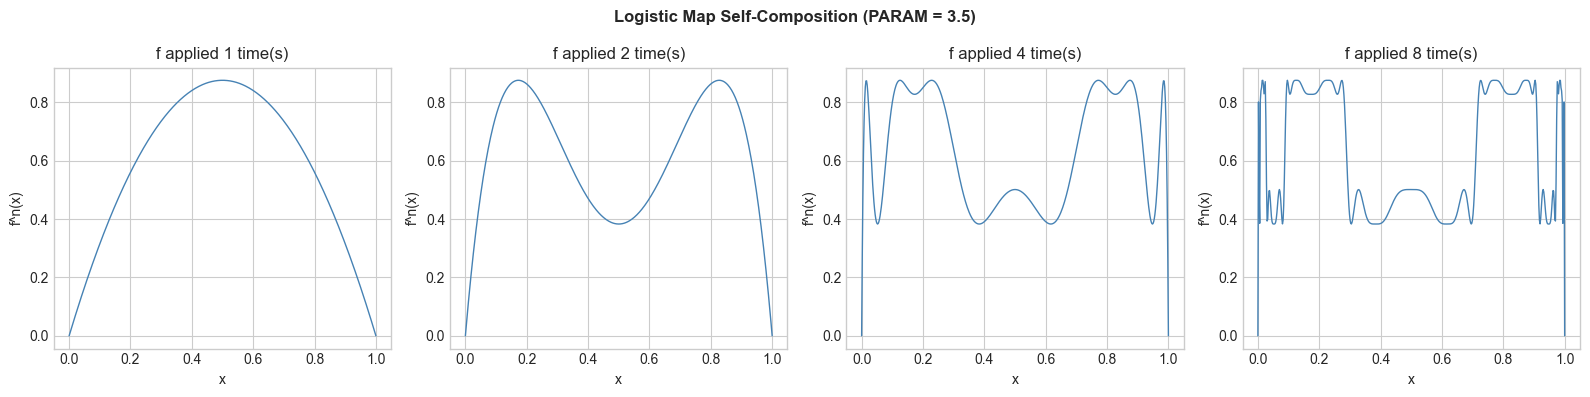

In [4]:
# --- Experiment 1: How deep composition changes a function's behavior ---
# Hypothesis: Composing a function with itself repeatedly creates increasingly complex shapes.
# Try: change the base function to x*(1-x) (logistic map — reappears in ch077)

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

PARAM = 3.5  # <-- try changing this between 0 and 4

def logistic(x):
    return PARAM * x * (1 - x)

def iterate(f, n_times):
    """Return f composed with itself n_times."""
    def iterated(x):
        result = x
        for _ in range(n_times):
            result = f(result)
        return result
    return iterated

x = np.linspace(0, 1, 500)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n in zip(axes, [1, 2, 4, 8]):
    fn = iterate(logistic, n)
    with np.errstate(invalid='ignore'):
        y = fn(x)
    ax.plot(x, np.clip(y, 0, 1), color='steelblue', linewidth=1)
    ax.set_title(f'f applied {n} time(s)')
    ax.set_xlabel('x')
    ax.set_ylabel('f^n(x)')

plt.suptitle(f'Logistic Map Self-Composition (PARAM = {PARAM})', fontweight='bold')
plt.tight_layout()
plt.show()
# With PARAM=3.5, you see chaos emerging — this is ch077's preview.

---

## 7. Exercises

**Easy 1.** If f(x) = 2x and g(x) = x + 3, compute (f∘g)(5) and (g∘f)(5) by hand. Verify in Python. *(Expected: f∘g=16, g∘f=13)*

**Easy 2.** Find two functions f and g such that f∘g = g∘f. (Hint: try both as linear functions ax+b with specific a and b values.) *(Expected: e.g. both f(x)=2x, g(x)=3x)*

**Medium 1.** Extend the `compose` function from Section 4 to support composition of two functions symbolically: given string representations `'x+1'` and `'x**2'`, produce the string `'(x**2)+1'` for (f∘g). *(Hint: string substitution)*

**Medium 2.** A data preprocessing pipeline has these steps: (1) subtract mean, (2) divide by std, (3) clip to [-3, 3], (4) apply tanh. Build this as a composition and apply it to an array of 1000 random values. Show before/after histograms. *(Hint: use compose with lambdas that close over computed mean and std)*

**Hard.** Show that for differentiable functions, the chain rule is the derivative of a composition: (f∘g)'(x) = f'(g(x)) · g'(x). Verify this numerically using finite differences for f(x)=sin(x), g(x)=x², at x=1.0. Compare your numerical (f∘g)' against f'(g(x))·g'(x) computed analytically. *(Challenge: This is the basis of backpropagation in neural networks — reappears in ch216)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Image Processing Pipeline as Function Composition ---
# Problem: Build an image preprocessing pipeline using pure function composition.
# Dataset: Simulated grayscale image (2D array).
# Task: Build composable image transforms and visualize the pipeline stages.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Generate synthetic grayscale image
np.random.seed(42)
SIZE = 64
x_grid, y_grid = np.meshgrid(np.linspace(0, 1, SIZE), np.linspace(0, 1, SIZE))
image = (np.sin(8 * np.pi * x_grid) * np.cos(6 * np.pi * y_grid)
         + 0.3 * np.random.randn(SIZE, SIZE))
image = (image - image.min()) / (image.max() - image.min())  # normalize to [0,1]

# Pure image transform functions (all take and return 2D arrays)
def add_noise(sigma=0.05):
    def _fn(img):
        np.random.seed(99)
        return np.clip(img + np.random.normal(0, sigma, img.shape), 0, 1)
    return _fn

def threshold(cutoff=0.5):
    """Binarize: pixels > cutoff → 1, else → 0."""
    return lambda img: (img > cutoff).astype(float)

def invert(img):
    return 1 - img

def blur(kernel_size=3):
    """Simple box blur using convolution."""
    def _fn(img):
        kernel = np.ones((kernel_size, kernel_size)) / kernel_size**2
        from numpy.fft import fft2, ifft2
        # Pad kernel to image size
        k_pad = np.zeros_like(img)
        ks = kernel_size // 2
        k_pad[:kernel_size, :kernel_size] = kernel
        blurred = np.real(ifft2(fft2(img) * fft2(k_pad)))
        return np.clip(blurred, 0, 1)
    return _fn

# Build pipeline
pipeline_stages = [
    ('Original',         lambda img: img),
    ('Blurred',          blur(5)),
    ('Noisy',            add_noise(0.1)),
    ('Thresholded',      threshold(0.5)),
    ('Inverted',         invert),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
current = image.copy()

for ax, (label, fn) in zip(axes, pipeline_stages):
    current = fn(current)
    ax.imshow(current, cmap='gray', vmin=0, vmax=1)
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Image Processing as Function Composition', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What we covered:**
- Composition (f∘g)(x) = f(g(x)) chains functions; g is applied first
- Composition is not commutative: f∘g ≠ g∘f in general
- Composition is associative: grouping does not change result
- Complex transformations (neural networks, pipelines) are compositions of simpler functions

**Backward connection:** Extends ch052's pipeline pattern with formal mathematical structure.

**Forward connections:**
- In ch055 (Inverse Functions), we ask: when does the composition f∘g = identity? That's when g is the inverse of f.
- The chain rule (ch215) is the derivative rule for composed functions — this is the mathematical foundation of backpropagation
- In ch168 (Linear Transformations), matrix multiplication is precisely composition of linear functions